In [1]:
import sys
import os

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm

sys.path.insert(0, "../code")
import measure_signal as ms
import dataset_utils as du
from Pipeline1_SNR_datasets import execute_specsnr_algorithm

plt.style.use("/home/2649/repos/foxstyle/custom.mplstyle")

In [2]:
dir_project = "/lustre/lrspec/users/2649/SNRvsR"
dir_data = os.path.join(dir_project, "datasets")
dir_models = os.path.join(dir_project, "models")

folder_snr_arr = [
    # "SNR000.5",
    # "SNR000.6",
    # "SNR000.7",
    # "SNR000.8",
    # "SNR000.9",
    "SNR001",
    # "SNR001.25",
    # "SNR001.5",
    # "SNR001.75",
    # "SNR002",
    # "SNR002.5",
    "SNR005",
    # "SNR020",
    "SNR025",
    # "SNR050",
    # "SNR100",
][::-1]
folder_R_arr = [
    # "R010",
    # "R015",
    # "R020",
    "R025",
    # "R030",
    # "R035",
    # "R040",
    # "R045",
    "R050",
    "R100",
    # "R200",
    # "R300",
    # "R400",
    # "R500",
][::-1]

In [3]:
files = np.zeros((len(folder_snr_arr), len(folder_R_arr)), dtype=object)
spec_arr = np.zeros((len(folder_snr_arr), len(folder_R_arr)), dtype=float)

In [4]:
choose_name = "sn1981b"
choose_phase = -1.5
choose_card = 1

file_original = "/home/2649/repos/spec_res/data/forSNR/dataset.parquet"
df = pd.read_parquet(file_original)
wvl0, spectra0, df_meta0 = du.unpack_dataset(df)

mask0 = df_meta0["SN Name"] == choose_name
mask0 &= df_meta0["Spectrum Phase"] == choose_phase
mask0 &= df_meta0["Spectrum Cardinality"] == choose_card
        
ind0 = df_meta0[mask0].index
assert len(ind0) == 1
ind0 = ind0[0]

specsnr0 = ms.SpectrumSNR(
    df_meta0.loc[ind0, "SN Name"],
    df_meta0.loc[ind0, "SN Subtype"],
    df_meta0.loc[ind0, "Spectrum Phase"],
    wvl0,
    spectra0[ind0])

execute_specsnr_algorithm(
    specsnr0,
    df_meta0.loc[ind0, "Denoising Parameter"],
    df_meta0.loc[ind0, "minima_i"],
    df_meta0.loc[ind0, "searchBlu"],
    df_meta0.loc[ind0, "searchRed"],
    df_meta0.loc[ind0, "maxBlu"],
    df_meta0.loc[ind0, "maxRed"],
    df_meta0.loc[ind0, "noiseWindowBlu"],
    df_meta0.loc[ind0, "noiseWindowRed"],
    df_meta0.loc[ind0, "useBlu"],
    df_meta0.loc[ind0, "useRed"],
    normalize=False,
    specsnr_original=None,
)

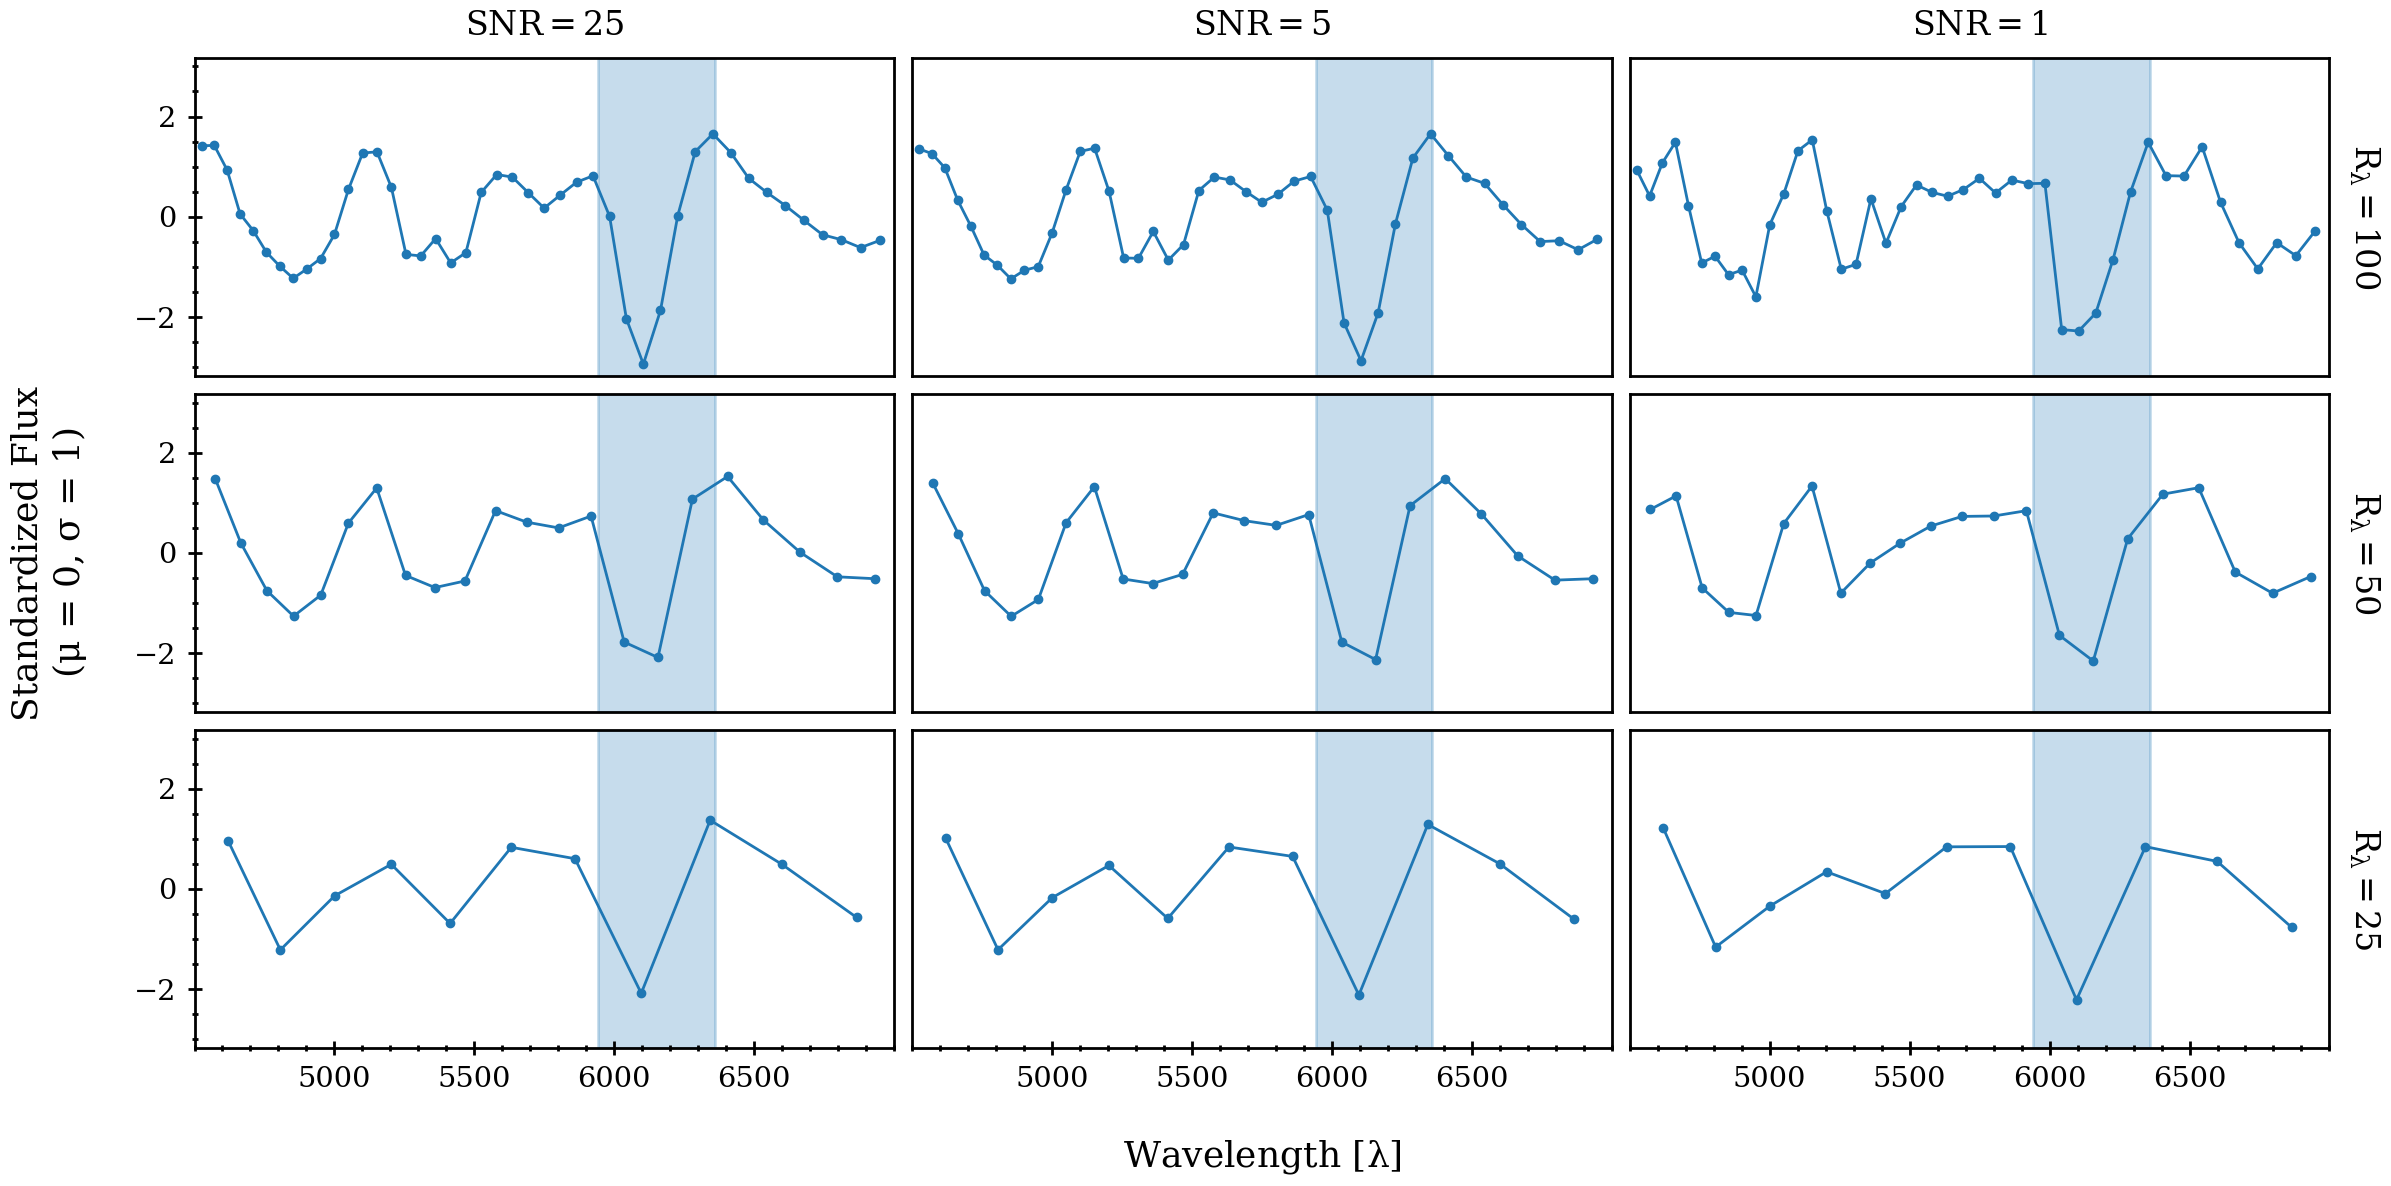

In [5]:
fig, axes = plt.subplots(
    ncols=len(folder_snr_arr),
    nrows=len(folder_R_arr),
    sharex=True,
    sharey=True,
    figsize=(24, 12))
axes.flatten()[0].set_xlim((4500, 7000))


spec_arr = []
for i, folder_snr in enumerate(folder_snr_arr):
    spec_arr.append([])
    for j, folder_R in enumerate(folder_R_arr):
        dir_datasets = os.path.join(dir_data, folder_snr, folder_R)
        file_data = os.path.join(dir_datasets, "dataset_SNRclipped_tts_augmented-TST_rebinned_masked_standardized.parquet")
        assert os.path.isfile(file_data)
        
        df = pd.read_parquet(file_data)
        wvl, spectra, df_meta = du.unpack_dataset(df)
        
        mask = df_meta["SN Name"] == choose_name
        mask &= df_meta["Spectrum Phase"] == choose_phase
        mask &= df_meta["Spectrum Cardinality"] == choose_card
        
        ind = df_meta[mask].index
        assert len(ind) == 1
        ind = ind[0]
        choose_spec = spectra[ind]

        # specsnr = ms.SpectrumSNR(
        #     df_meta.loc[ind, "SN Name"],
        #     df_meta.loc[ind, "SN Subtype"],
        #     df_meta.loc[ind, "Spectrum Phase"],
        #     wvl,
        #     spectra[ind])
        
        # execute_specsnr_algorithm(
        #     specsnr,
        #     df_meta.loc[ind, "Denoising Parameter"],
        #     df_meta.loc[ind, "minima_i"],
        #     df_meta.loc[ind, "searchBlu"],
        #     df_meta.loc[ind, "searchRed"],
        #     df_meta.loc[ind, "maxBlu"],
        #     df_meta.loc[ind, "maxRed"],
        #     df_meta.loc[ind, "noiseWindowBlu"],
        #     df_meta.loc[ind, "noiseWindowRed"],
        #     df_meta.loc[ind, "useBlu"],
        #     df_meta.loc[ind, "useRed"],
        #     normalize=False,
        #     specsnr_original=specsnr0,
        # )

        SNR = float(folder_snr.split('SNR')[-1])
        if int(SNR) == SNR:
            SNR = int(SNR)
        RL = int(folder_R.split('R')[-1])
        
        axes[j, i].plot(wvl, choose_spec, marker="o")
        axes[j, i].axvspan(
            specsnr0.wvl_shoulder_blu, specsnr0.wvl_shoulder_red,
            color="tab:blue",
            alpha=0.25,
        )

        if i == 2:
            axes[j, i].text(
                1.05,
                0.5,
                f"$R_\lambda={RL}$",
                ha="center", va="center", rotation=270,
                size=24,
                transform=axes[j, i].transAxes)
        if j == 0:
            axes[j, i].text(
                0.50,
                1.05,
                f"$SNR = {SNR}$",
                ha="center", va="bottom",
                size=24,
                transform=axes[j, i].transAxes)

        axes[j, i].tick_params(axis="both", which="both", direction="inout", bottom=False, top=False, left=False, right=False)
        
    #     break
    # break
axes[2, 1].set_xlabel("\nWavelength [$\lambda$]", size=26)
axes[1, 0].set_ylabel("Standardized Flux\n($\mu$ = 0, $\sigma$ = 1)\n", size=26)

ylim1 = np.max(np.abs(axes[0, 0].get_ylim()))
ylim0 = -ylim1
axes[0, 0].set_ylim((ylim0, ylim1))
axes[0, 0].set_xticks([5000, 5500, 6000, 6500])

axes[0, 0].tick_params(axis="both", which="both", direction="inout", bottom=False, top=False, left=True, right=False)
axes[1, 0].tick_params(axis="both", which="both", direction="inout", bottom=False, top=False, left=True, right=False)
axes[2, 0].tick_params(axis="both", which="both", direction="inout", bottom=True, top=False, left=True, right=False)
axes[2, 1].tick_params(axis="both", which="both", direction="inout", bottom=True, top=False, left=False, right=False)
axes[2, 2].tick_params(axis="both", which="both", direction="inout", bottom=True, top=False, left=False, right=False)

fig.tight_layout()
fig.savefig("spectrum_SNR_R.pdf")
fig.savefig("spectrum_SNR_R.png")
fig.show()